# Análisis Exploratorio de Datos (EDA) Agrícola: Análisis Municipio a Municipio y sus Varios Cultivos (2015-2024)

**Departamento:** Valle del Cauca  
**Enfoque Estructural:** El análisis se efectúa **municipio a municipio**, y **dentro de cada municipio se examinan sus varios cultivos** mediante subplots e identificadores visuales individuales.  
**Cálculos de Rentabilidad y Depuración:**  
- **Filtro de Rendimiento:** $0 < \text{Rendimiento} \le 100\text{ Ton}/\text{Ha}$ para depurar ceros y distorsiones atípicas.

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Carga de datos
data_sources = [
    Path('../data/silver_agri_modelo_base.csv'),
    Path('data/silver_agri_modelo_base.csv'),
    Path('../data/dataset_prediccion_rentabilidad.csv'),
    Path('data/dataset_prediccion_rentabilidad.csv'),
    Path('../data/dataset_consolidado_valle.csv'),
    Path('data/dataset_consolidado_valle.csv')
]
data_path = next((p for p in data_sources if p.exists()), Path('data/dataset_consolidado_valle.csv'))
print(f"Cargando dataset desde: {data_path}")

df_raw = pd.read_csv(data_path)

renames = {
    "nombre_cultivo": "cultivo",
    "precio": "precio_promedio_anual_sipsa",
    "indice_oni": "promedio_oni",
    "oni": "promedio_oni",
    "rendimiento_t_ha": "rendimiento_toneladas_ha",
    "id_municipio": "codigo_municipio",
}
df_raw = df_raw.rename(columns={k: v for k, v in renames.items() if k in df_raw.columns})

if "cultivo" in df_raw.columns:
    df_raw["cultivo"] = df_raw["cultivo"].astype(str).str.strip().str.title()

# Mapear municipio si solo existe codigo_municipio
if ("municipio" not in df_raw.columns or df_raw["municipio"].isnull().all()) and "codigo_municipio" in df_raw.columns:
    mun_path = Path('../data/municipios_valle_clean.csv') if Path('../data/municipios_valle_clean.csv').exists() else Path('data/municipios_valle_clean.csv')
    if mun_path.exists():
        df_mun_map = pd.read_csv(mun_path)[["codigo_municipio", "municipio"]]
        df_raw = pd.merge(df_raw, df_mun_map, on="codigo_municipio", how="left")
    else:
        cons_path = Path('../data/dataset_consolidado_valle.csv') if Path('../data/dataset_consolidado_valle.csv').exists() else Path('data/dataset_consolidado_valle.csv')
        if cons_path.exists():
            df_cons = pd.read_csv(cons_path)[["codigo_municipio", "municipio"]].drop_duplicates()
            df_raw = pd.merge(df_raw, df_cons, on="codigo_municipio", how="left")

if "municipio" not in df_raw.columns:
    df_raw["municipio"] = "Valle del Cauca"
else:
    df_raw["municipio"] = df_raw["municipio"].astype(str).str.strip().str.title()

crops_path = Path('../data/cultivos_valle.csv') if Path('../data/cultivos_valle.csv').exists() else Path('data/cultivos_valle.csv')
if "produccion_toneladas" not in df_raw.columns and crops_path.exists():
    df_crops = pd.read_csv(crops_path)
    cols_to_add = [c for c in ["produccion_toneladas", "rendimiento_toneladas_ha"] if c in df_crops.columns and c not in df_raw.columns]
    if cols_to_add and "cultivo" in df_raw.columns and "municipio" in df_raw.columns:
        df_crops["municipio_tmp"] = df_crops["municipio"].astype(str).str.strip().str.lower()
        df_crops["cultivo_tmp"] = df_crops["cultivo"].astype(str).str.strip().str.lower()
        df_raw["municipio_tmp"] = df_raw["municipio"].astype(str).str.strip().str.lower()
        df_raw["cultivo_tmp"] = df_raw["cultivo"].astype(str).str.strip().str.lower()
        df_sub = df_crops[["anio", "municipio_tmp", "cultivo_tmp"] + cols_to_add].drop_duplicates(subset=["anio", "municipio_tmp", "cultivo_tmp"])
        df_raw = pd.merge(df_raw, df_sub, on=["anio", "municipio_tmp", "cultivo_tmp"], how="left").drop(columns=["municipio_tmp", "cultivo_tmp"])

if "produccion_toneladas" not in df_raw.columns:
    if "hectareas_cosechadas" in df_raw.columns and "rendimiento_toneladas_ha" in df_raw.columns:
        df_raw["produccion_toneladas"] = df_raw["hectareas_cosechadas"] * df_raw["rendimiento_toneladas_ha"]
    else:
        df_raw["produccion_toneladas"] = 0.0

if "rendimiento_toneladas_ha" not in df_raw.columns:
    df_raw["rendimiento_toneladas_ha"] = np.where(
        df_raw["hectareas_cosechadas"] > 0,
        df_raw["produccion_toneladas"] / df_raw["hectareas_cosechadas"],
        np.nan
    )

if "precio_promedio_anual_sipsa" not in df_raw.columns or df_raw["precio_promedio_anual_sipsa"].isnull().all():
    cons_path = Path('../data/dataset_consolidado_valle.csv') if Path('../data/dataset_consolidado_valle.csv').exists() else Path('data/dataset_consolidado_valle.csv')
    if cons_path.exists():
        df_prices = pd.read_csv(cons_path)
        p_col = "precio_promedio_anual_sipsa" if "precio_promedio_anual_sipsa" in df_prices.columns else ("precio" if "precio" in df_prices.columns else None)
        c_col = "cultivo" if "cultivo" in df_prices.columns else ("nombre_cultivo" if "nombre_cultivo" in df_prices.columns else None)
        if p_col and c_col and "anio" in df_prices.columns:
            df_prices["cultivo_clean"] = df_prices[c_col].astype(str).str.strip().str.title()
            df_sub_price = df_prices[["anio", "cultivo_clean", p_col]].rename(columns={"cultivo_clean": "cultivo", p_col: "precio_promedio_anual_sipsa"}).dropna().groupby(["anio", "cultivo"])["precio_promedio_anual_sipsa"].mean().reset_index()
            if "precio_promedio_anual_sipsa" in df_raw.columns:
                df_raw = df_raw.drop(columns=["precio_promedio_anual_sipsa"])
            df_raw = pd.merge(df_raw, df_sub_price, on=["anio", "cultivo"], how="left")

if "precio_promedio_anual_sipsa" not in df_raw.columns:
    df_raw["precio_promedio_anual_sipsa"] = np.nan

num_cols = ['hectareas_sembradas', 'hectareas_cosechadas', 'produccion_toneladas', 'rendimiento_toneladas_ha', 'precio_promedio_anual_sipsa', 'promedio_oni']
for col in num_cols:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col].astype(str).str.replace(',', '.'), errors='coerce')

df = df_raw[df_raw['anio'] >= 2015].copy()

# Estandarización de grupos
if 'tipo_cultivo' in df.columns:
    df['tipo_cultivo_clean'] = df['tipo_cultivo'].astype(str).str.strip().str.title()
else:
    df['tipo_cultivo_clean'] = "General"

mapping_grupos = {
    'Cultivos Tropicales Tradicionales': 'Tropicales Tradicionales',
    'Cultivos Tropicales Tradicionales ': 'Tropicales Tradicionales',
    'Raíces Y Tubérculos': 'Raíces y Tubérculos',
    'Cultivos Para Condimentos Y Bebidas Medicinales Y Aromáticas': 'Aromáticas y Medicinales',
    'Cultivos Para Condimentos, Bebidas Medicinales Y Aromáticas': 'Aromáticas y Medicinales',
}
df['grupo_cultivo'] = df['tipo_cultivo_clean'].replace(mapping_grupos)

df['kilos_cosechados'] = df['produccion_toneladas'] * 1000.0
df['valor_venta'] = df['kilos_cosechados'] * df['precio_promedio_anual_sipsa']
df['valor_venta_millones'] = df['valor_venta'] / 1e6

df_val = df[(df['kilos_cosechados'] > 0) & (df['valor_venta_millones'] > 0)].dropna(subset=['valor_venta_millones'])
df_rend_val = df[(df['rendimiento_toneladas_ha'] > 0) & (df['rendimiento_toneladas_ha'] <= 100)].copy()

muns_evaluados = sorted(df['municipio'].dropna().unique().tolist())

print(f"Dataset cargado (2015-2024). Registros totales: {len(df):,}")
print(f"Registros con Valor Venta (Precios SIPSA válidos): {df['valor_venta'].notnull().sum():,}")
print(f"Todos los Municipios evaluados: {len(muns_evaluados)} | Todos los Cultivos evaluados: {df['cultivo'].nunique()}")

Cargando dataset desde: ../data/silver_agri_modelo_base.csv
Dataset cargado (2015-2024). Registros totales: 11,782
Registros con Valor Venta (Precios SIPSA válidos): 4,035
Todos los Municipios evaluados: 42 | Todos los Cultivos evaluados: 91


## 1. Valor de Venta Estimado por Municipio y sus Varios Cultivos

Analizamos la totalidad de las parejas `(municipio - cultivo)` en generación de ingreso bruto acumulado ($COP$).

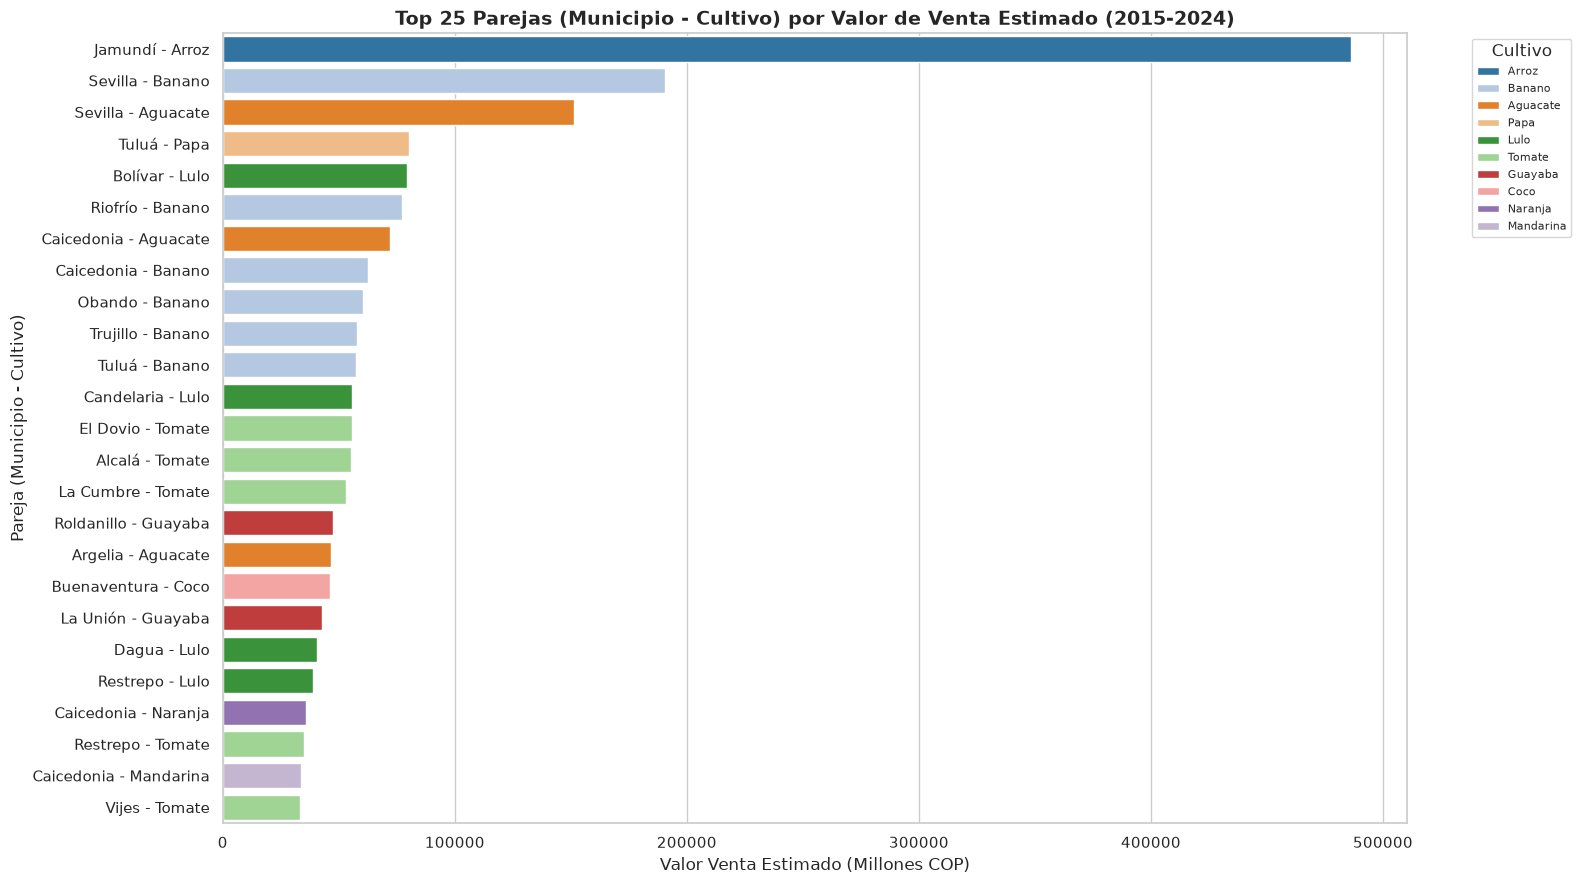

--- Resumen de TODAS las Parejas (Municipio - Cultivo) Evaluadas (500 parejas con precio SIPSA) ---


,municipio,cultivo,total_kilos_cosechados,precio_promedio_sipsa,total_valor_venta_millones
641,Jamundí,Arroz,171495000.0,2850.227778,486247.928400
1046,Sevilla,Banano,173504000.0,1124.995556,190617.306040
1040,Sevilla,Aguacate,61840600.0,3593.898000,151302.779200
1187,Tuluá,Papa,63471000.0,1677.997143,80112.143600
132,Bolívar,Lulo,27430000.0,2890.872222,79295.466800
...,...,...,...,...,...
749,La Victoria,Habichuela,2500.0,3240.500000,8.101250
1297,Yotoco,Arveja,2000.0,3152.750000,6.305500
750,La Victoria,Lechuga,2500.0,1260.920000,3.152300
532,El Águila,Repollo,6250.0,620.000000,1.240000


In [2]:
resumen_mun_prod = df.groupby(['municipio', 'cultivo']).agg(
    anios_registrados=('anio', 'count'),
    total_hectareas_cosechadas=('hectareas_cosechadas', 'sum'),
    total_produccion_toneladas=('produccion_toneladas', 'sum'),
    total_kilos_cosechados=('kilos_cosechados', 'sum'),
    rendimiento_promedio_ton_ha=('rendimiento_toneladas_ha', 'mean'),
    precio_promedio_sipsa=('precio_promedio_anual_sipsa', 'mean'),
    total_valor_venta_millones=('valor_venta_millones', 'sum')
).reset_index()

top_ingreso = resumen_mun_prod.dropna(subset=['precio_promedio_sipsa']).sort_values('total_valor_venta_millones', ascending=False).copy()
top_ingreso['mun_cultivo'] = top_ingreso['municipio'] + ' - ' + top_ingreso['cultivo']

plt.figure(figsize=(16, 9))
sns.barplot(data=top_ingreso.head(25), x='total_valor_venta_millones', y='mun_cultivo', hue='cultivo', dodge=False, palette="tab20")
plt.title('Top 25 Parejas (Municipio - Cultivo) por Valor de Venta Estimado (2015-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Valor Venta Estimado (Millones COP)', fontsize=12)
plt.ylabel('Pareja (Municipio - Cultivo)', fontsize=12)
h, l = plt.gca().get_legend_handles_labels()
if h:
    plt.legend(h, l, title='Cultivo', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

print(f"--- Resumen de TODAS las Parejas (Municipio - Cultivo) Evaluadas ({len(top_ingreso)} parejas con precio SIPSA) ---")
display(top_ingreso[['municipio', 'cultivo', 'total_kilos_cosechados', 'precio_promedio_sipsa', 'total_valor_venta_millones']])

## 2. Diagramas de Dispersión Municipio a Municipio: Todos los Municipios y Todos sus Cultivos

Evaluamos para los **42 municipios del departamento** (en subplots independientes por cada territorio) las relaciones de **Kilos Cosechados vs. Valor Venta** y **Rendimiento (Ton/Ha) vs. Precio SIPSA ($/Kg)** para la totalidad de sus cultivos.

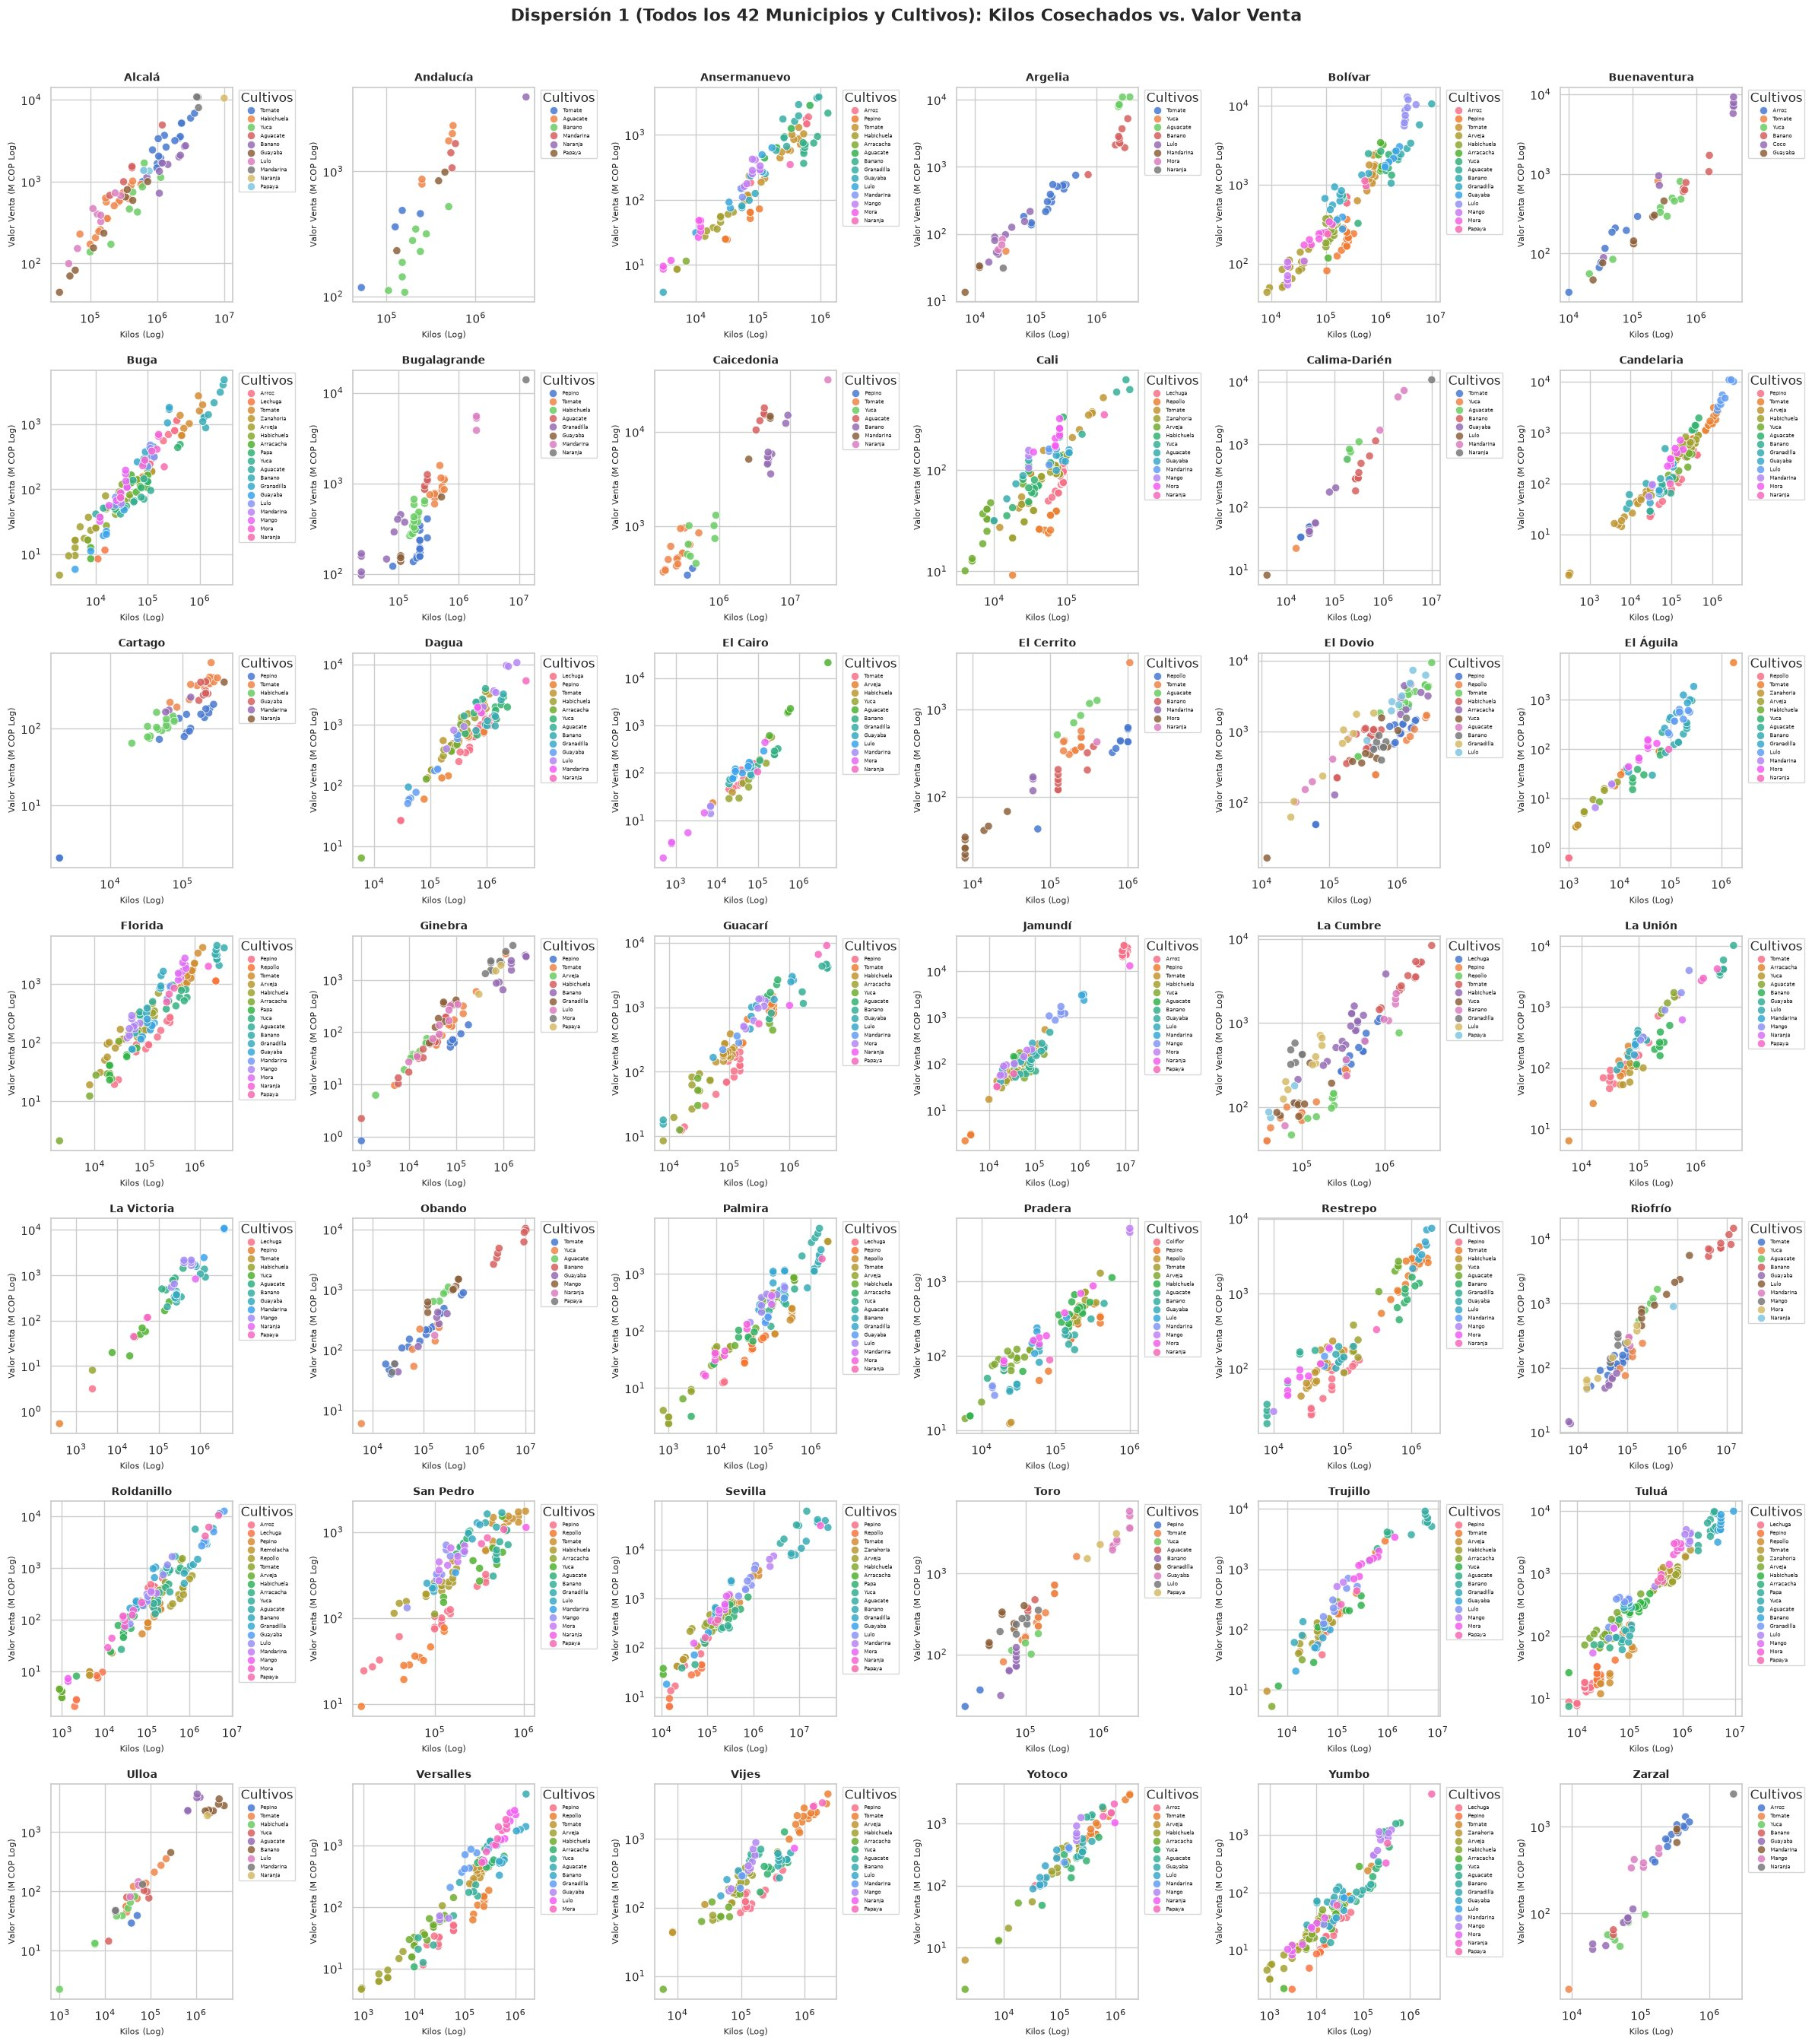

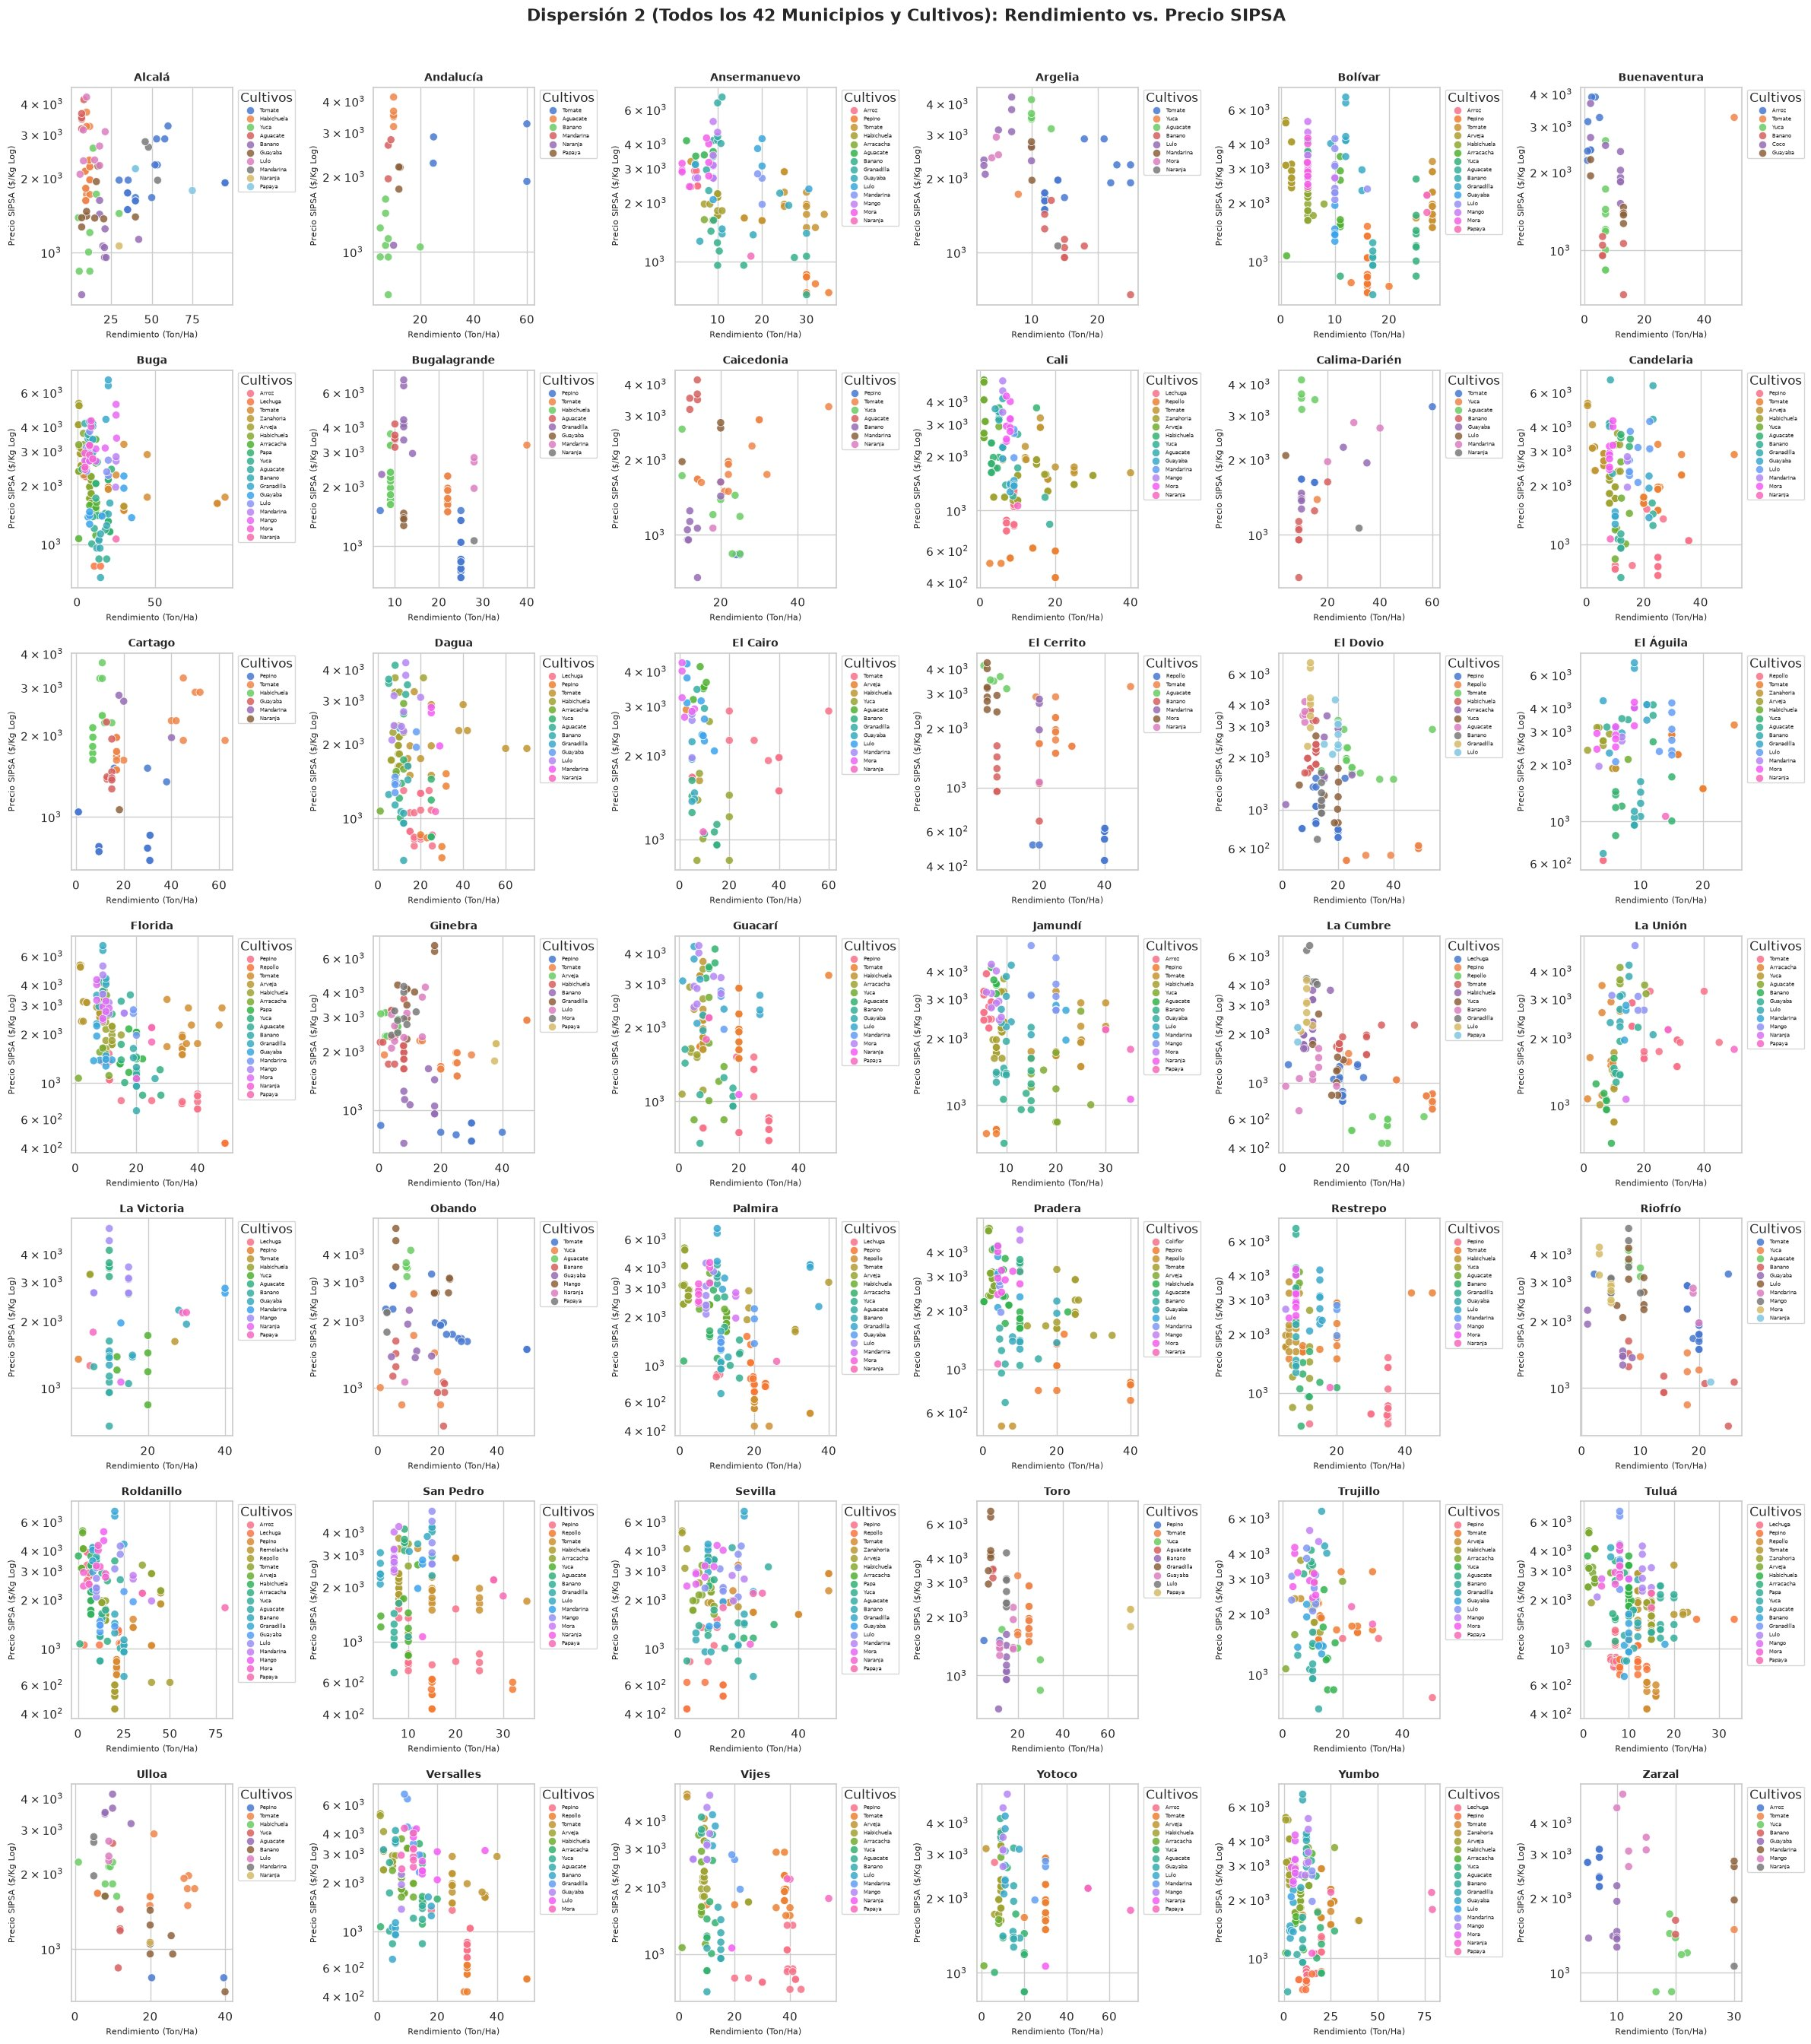

In [3]:
# Función auxiliar para renderizar todos los 42 municipios y todos sus cultivos sin filtro
def plot_grid_completo(df_data, x_col, y_col, x_label, y_label, title, use_log_x=False, use_log_y=False, draw_oni_line=False):
    n_muns = len(muns_evaluados)
    n_cols = 6
    n_rows = (n_muns + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 3.8 * n_rows))
    axes = axes.flatten()

    for idx, mun in enumerate(muns_evaluados):
        df_m = df_data[df_data['municipio'] == mun]
        if len(df_m) > 0:
            sns.scatterplot(ax=axes[idx], data=df_m, x=x_col, y=y_col, hue='cultivo', alpha=0.85, s=55)
            if draw_oni_line:
                axes[idx].axvline(0, color='red', linestyle='--', alpha=0.5)
            if use_log_x:
                axes[idx].set_xscale('log')
            if use_log_y:
                axes[idx].set_yscale('log')
            h, l = axes[idx].get_legend_handles_labels()
            if h:
                axes[idx].legend(h, l, bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=5, title='Cultivos')
        axes[idx].set_title(f'{mun}', fontsize=10, fontweight='bold')
        axes[idx].set_xlabel(x_label, fontsize=8)
        axes[idx].set_ylabel(y_label, fontsize=8)

    for j in range(idx + 1, len(axes)):
        axes[j].axis('off')

    plt.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# Dispersión 1: Kilos Cosechados vs. Valor Venta (Todos los Municipios y Cultivos)
plot_grid_completo(df_val, 'kilos_cosechados', 'valor_venta_millones', 'Kilos (Log)', 'Valor Venta (M COP Log)', 
                   'Dispersión 1 (Todos los 42 Municipios y Cultivos): Kilos Cosechados vs. Valor Venta', use_log_x=True, use_log_y=True)

# Dispersión 2: Rendimiento vs. Precio SIPSA (Todos los Municipios y Cultivos)
plot_grid_completo(df_rend_val.dropna(subset=['precio_promedio_anual_sipsa']), 'rendimiento_toneladas_ha', 'precio_promedio_anual_sipsa', 
                   'Rendimiento (Ton/Ha)', 'Precio SIPSA ($/Kg Log)', 
                   'Dispersión 2 (Todos los 42 Municipios y Cultivos): Rendimiento vs. Precio SIPSA', use_log_x=False, use_log_y=True)

## 3. Diagramas de Dispersión Municipio a Municipio: Hectáreas Cosechadas e Índice Climático ONI

Analizamos en la totalidad de los municipios el comportamiento de las hectáreas cosechadas y el efecto del índice climático ONI sobre todos sus cultivos.

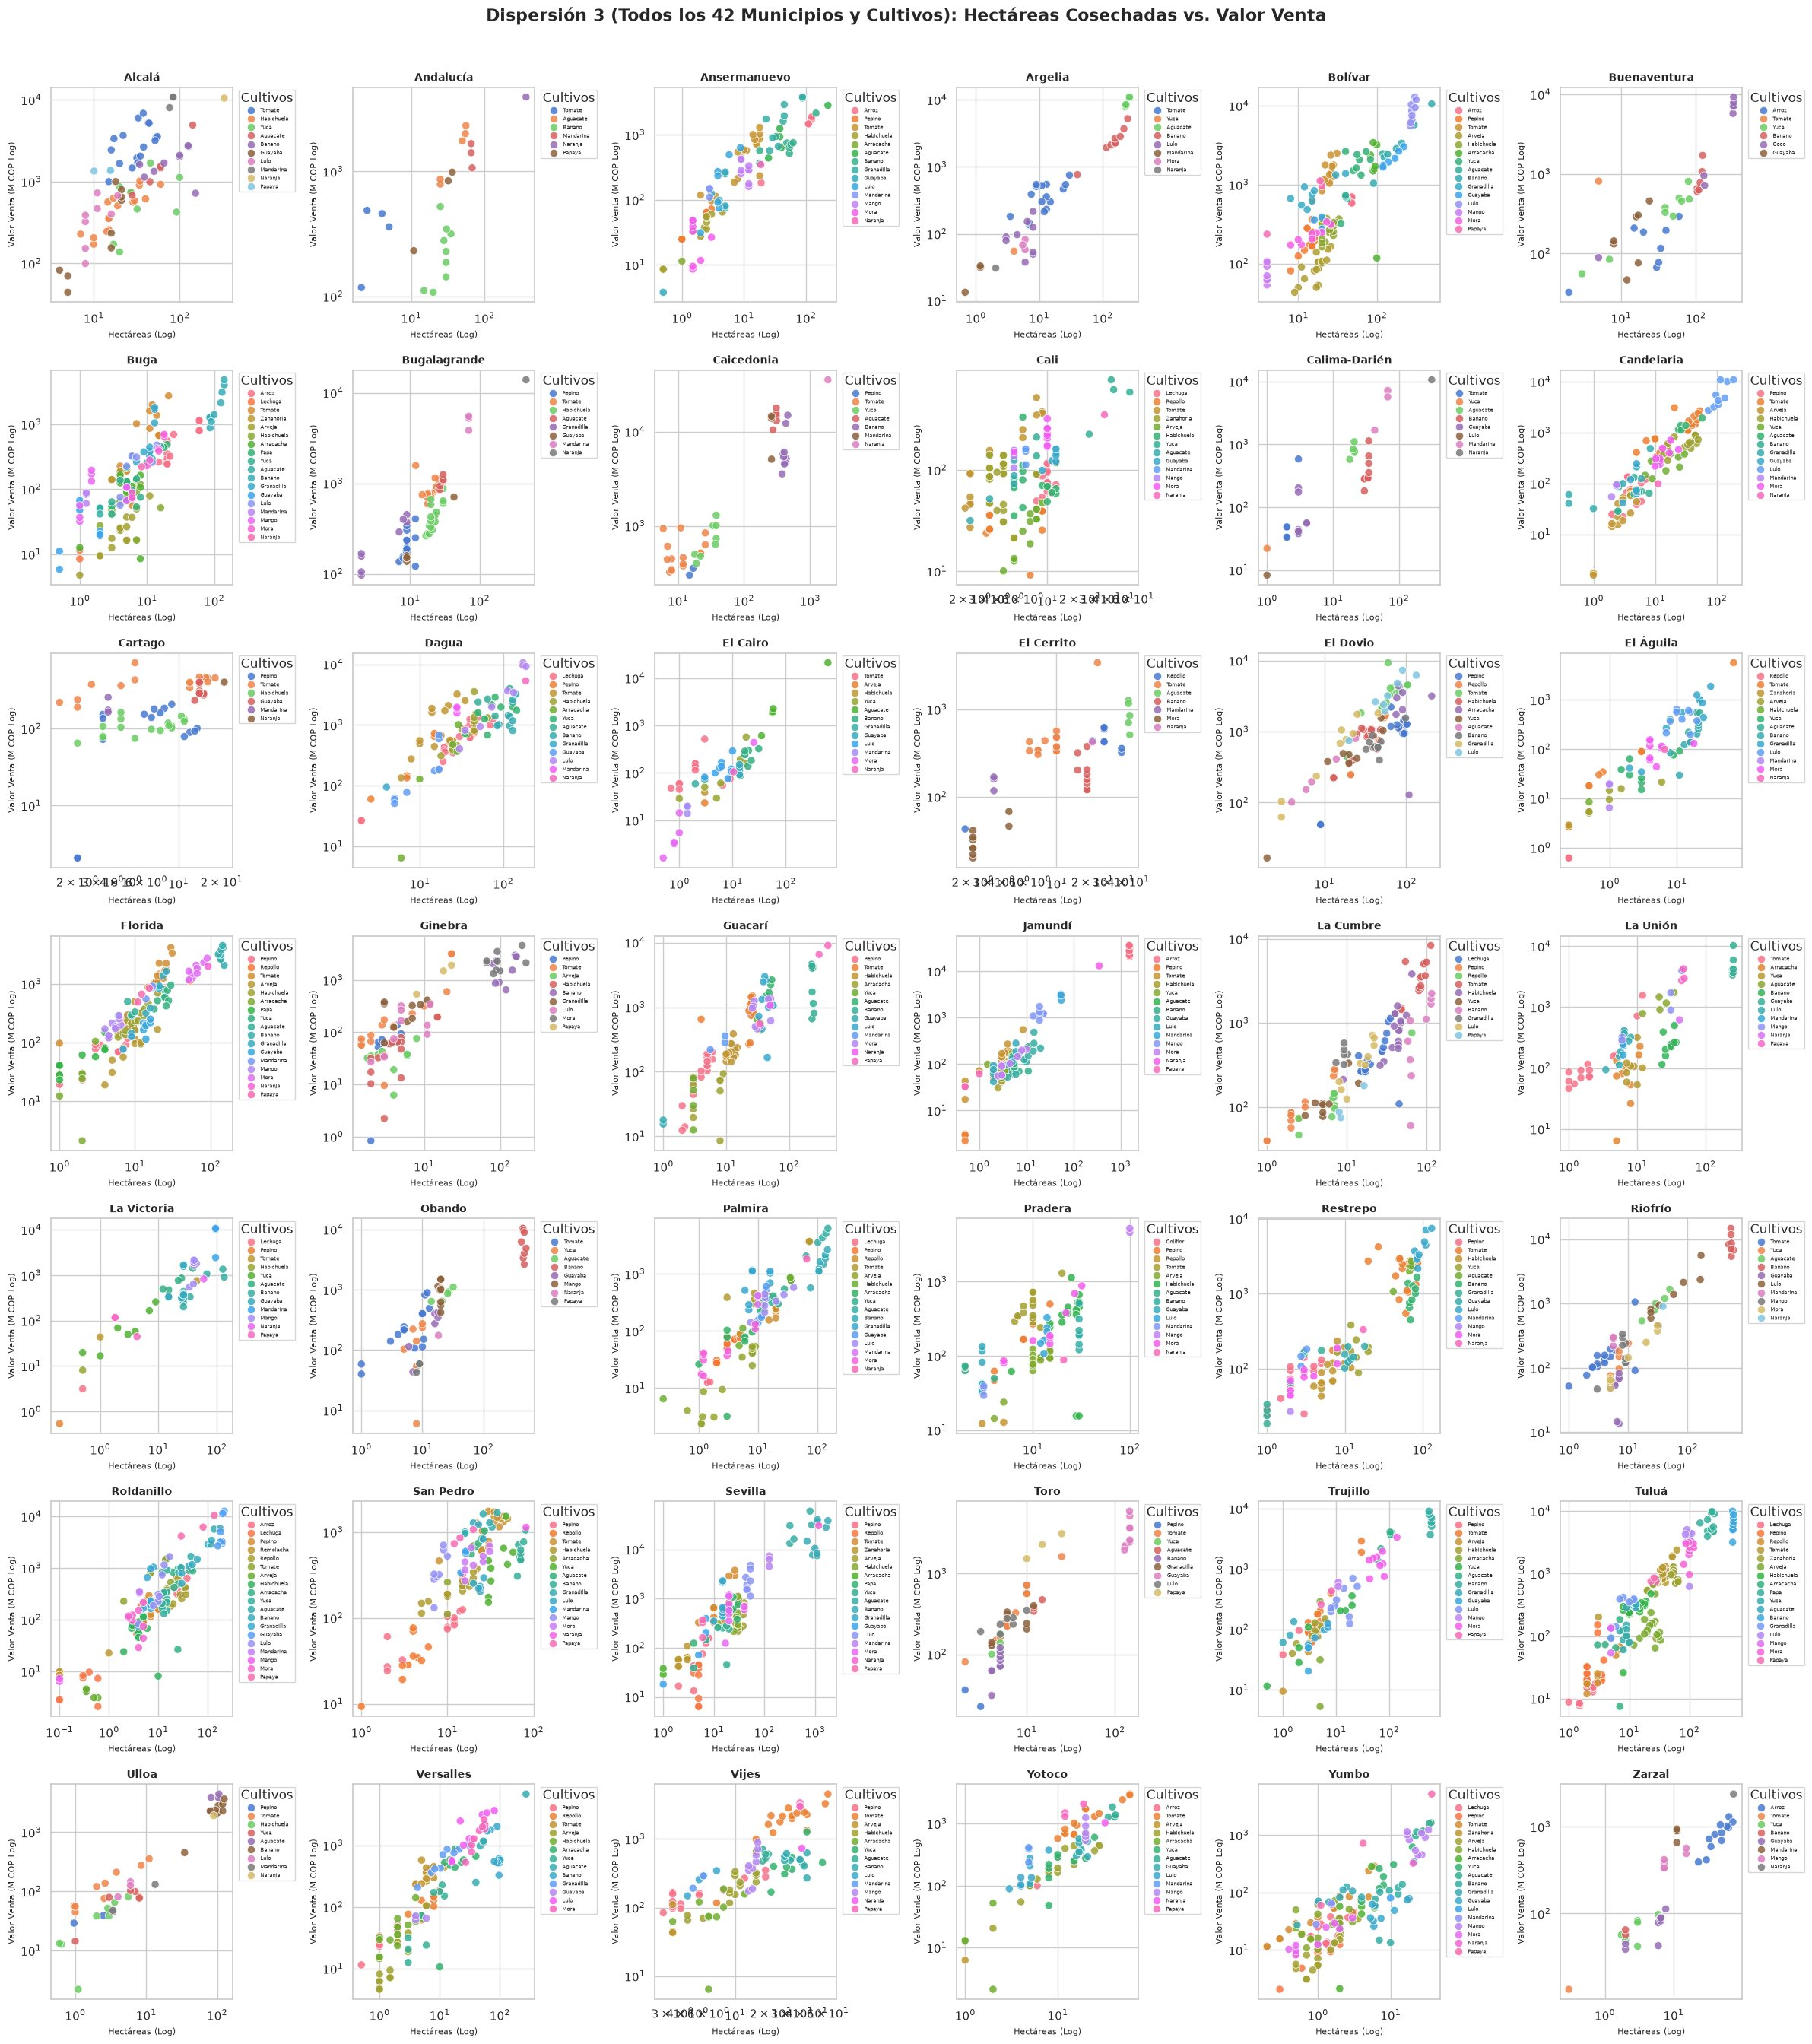

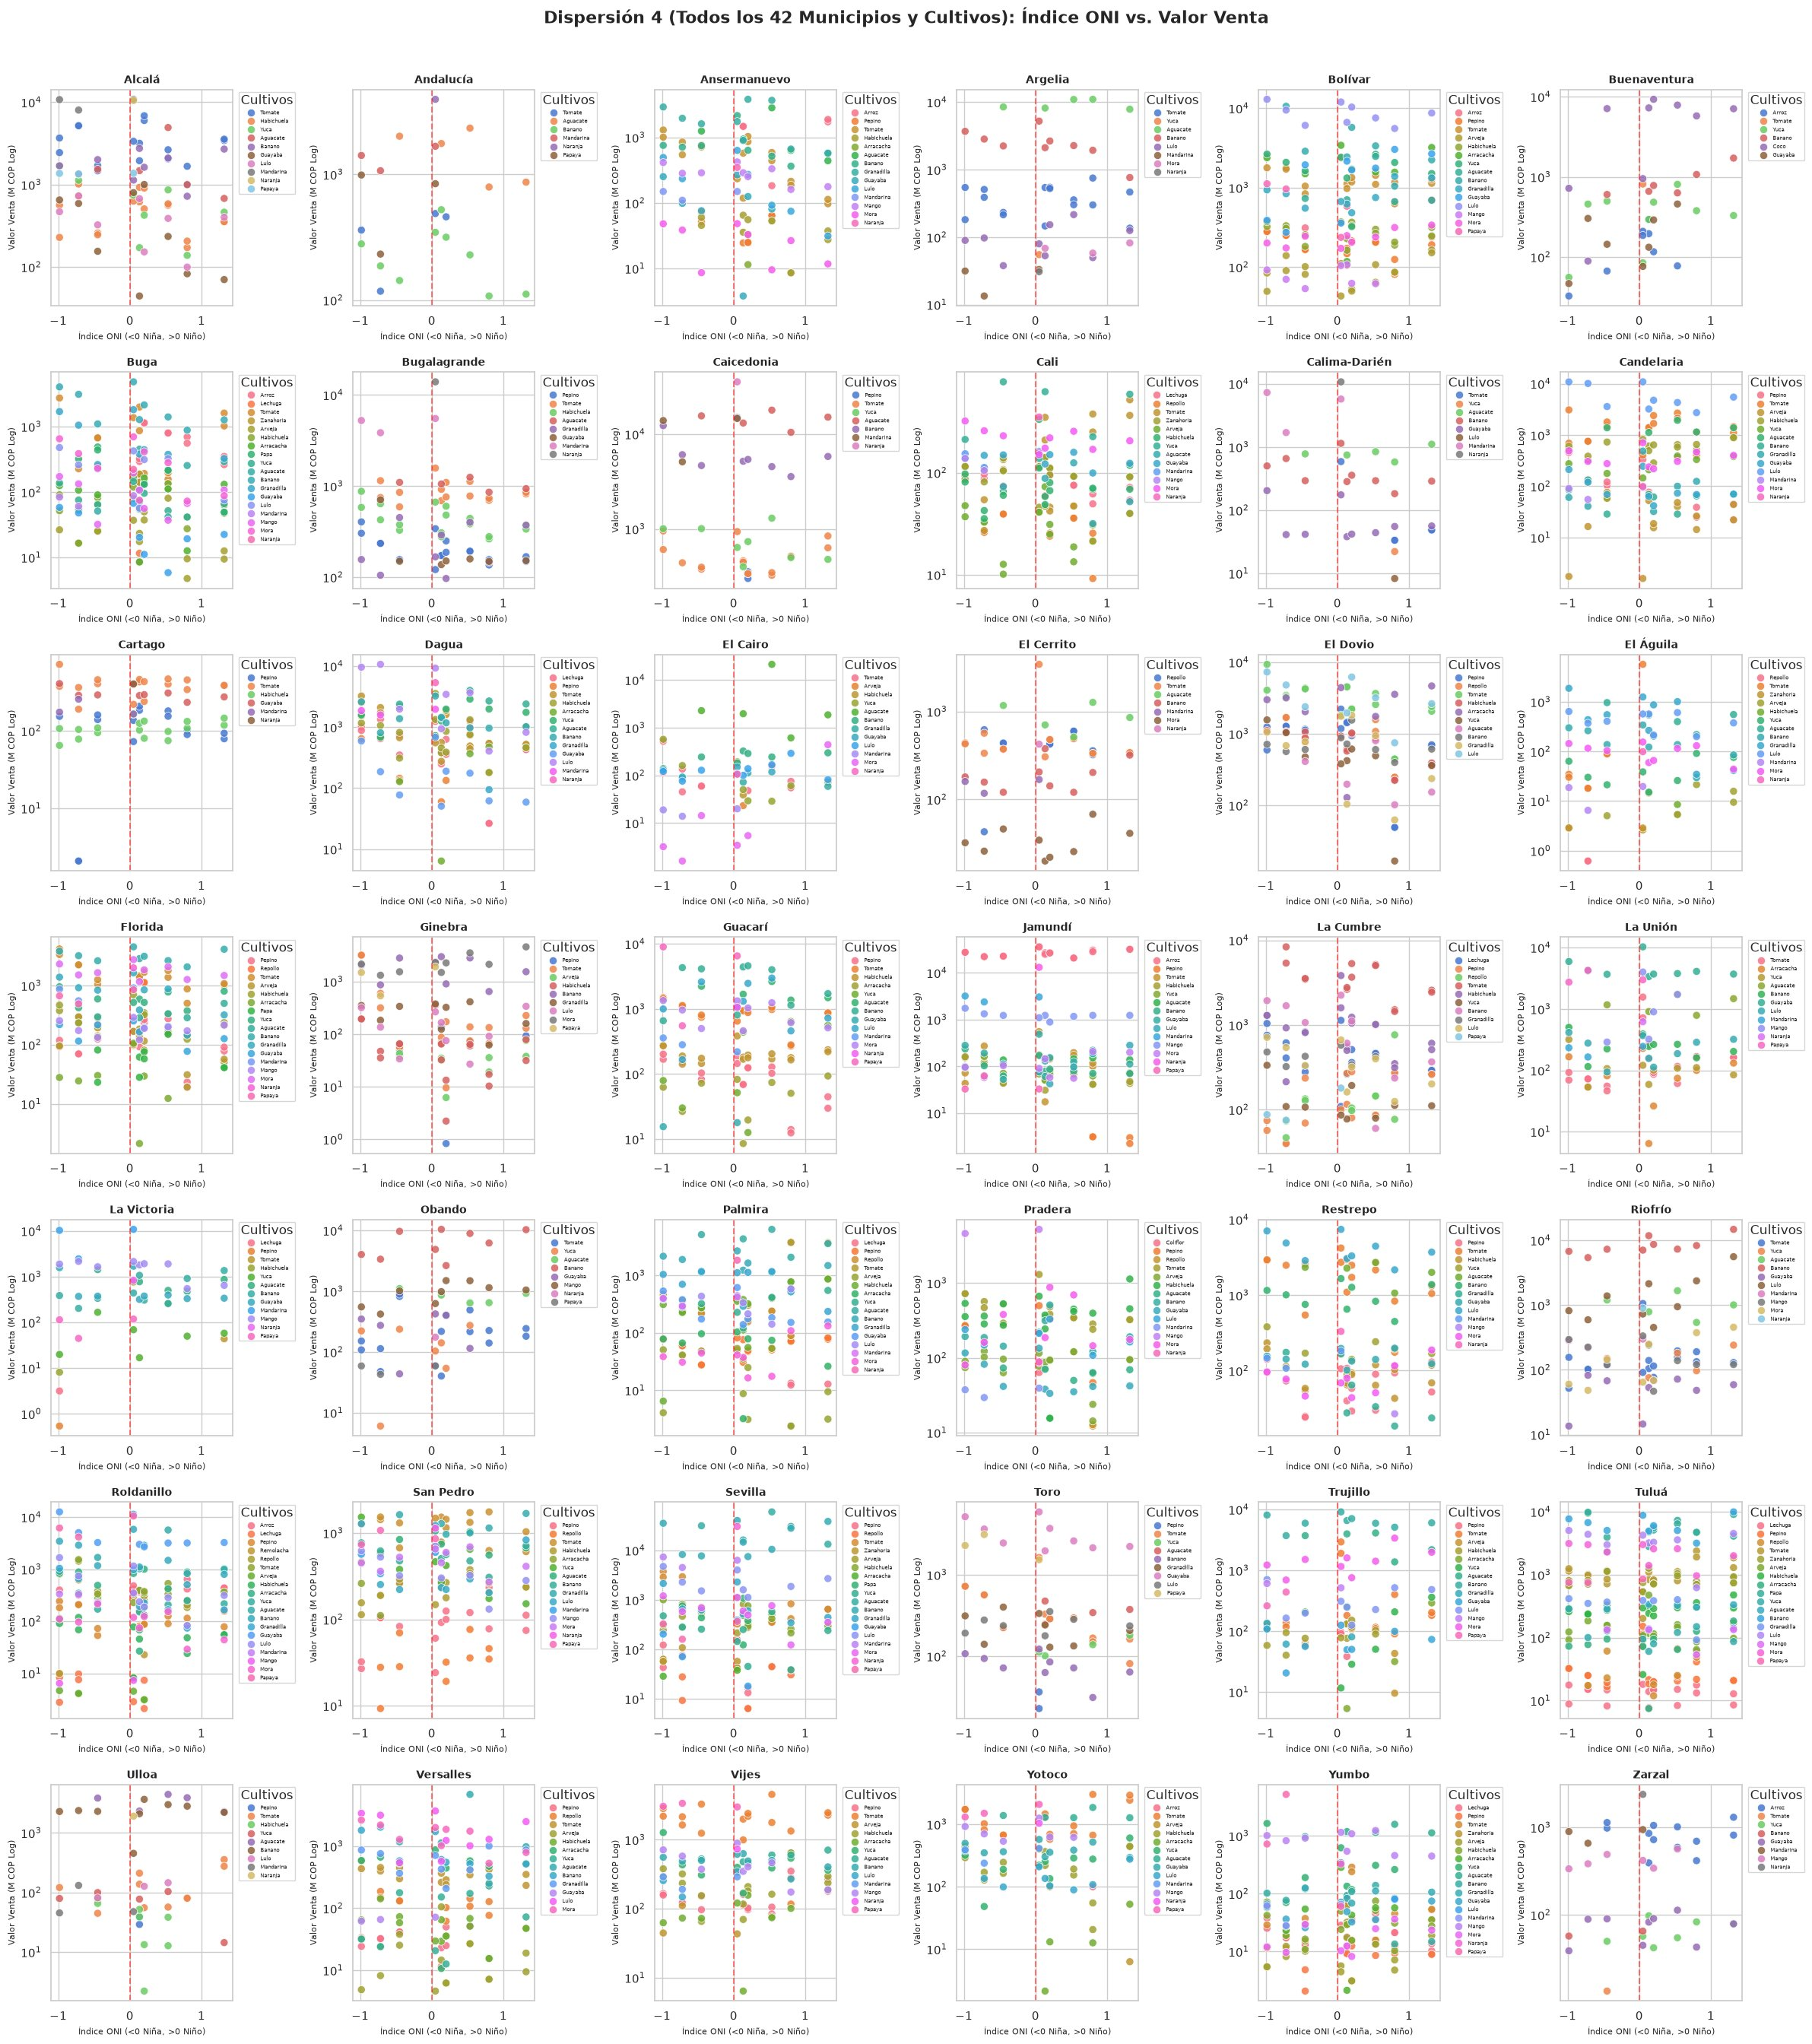

In [4]:
# Dispersión 3: Hectáreas Cosechadas vs. Valor Venta (Todos los Municipios y Cultivos)
plot_grid_completo(df_val, 'hectareas_cosechadas', 'valor_venta_millones', 'Hectáreas (Log)', 'Valor Venta (M COP Log)', 
                   'Dispersión 3 (Todos los 42 Municipios y Cultivos): Hectáreas Cosechadas vs. Valor Venta', use_log_x=True, use_log_y=True)

# Dispersión 4: Índice ONI vs. Valor Venta (Todos los Municipios y Cultivos)
plot_grid_completo(df_val, 'promedio_oni', 'valor_venta_millones', 'Índice ONI (<0 Niña, >0 Niño)', 'Valor Venta (M COP Log)', 
                   'Dispersión 4 (Todos los 42 Municipios y Cultivos): Índice ONI vs. Valor Venta', use_log_x=False, use_log_y=True, draw_oni_line=True)

## 4. Sensibilidad Climática ONI Municipio a Municipio: Rendimiento Agrícola (Ton/Ha) por Cultivo

Evaluamos el rendimiento de la totalidad de cultivos en todos los municipios frente a variaciones climáticas ONI (El Niño, La Niña y Neutro).

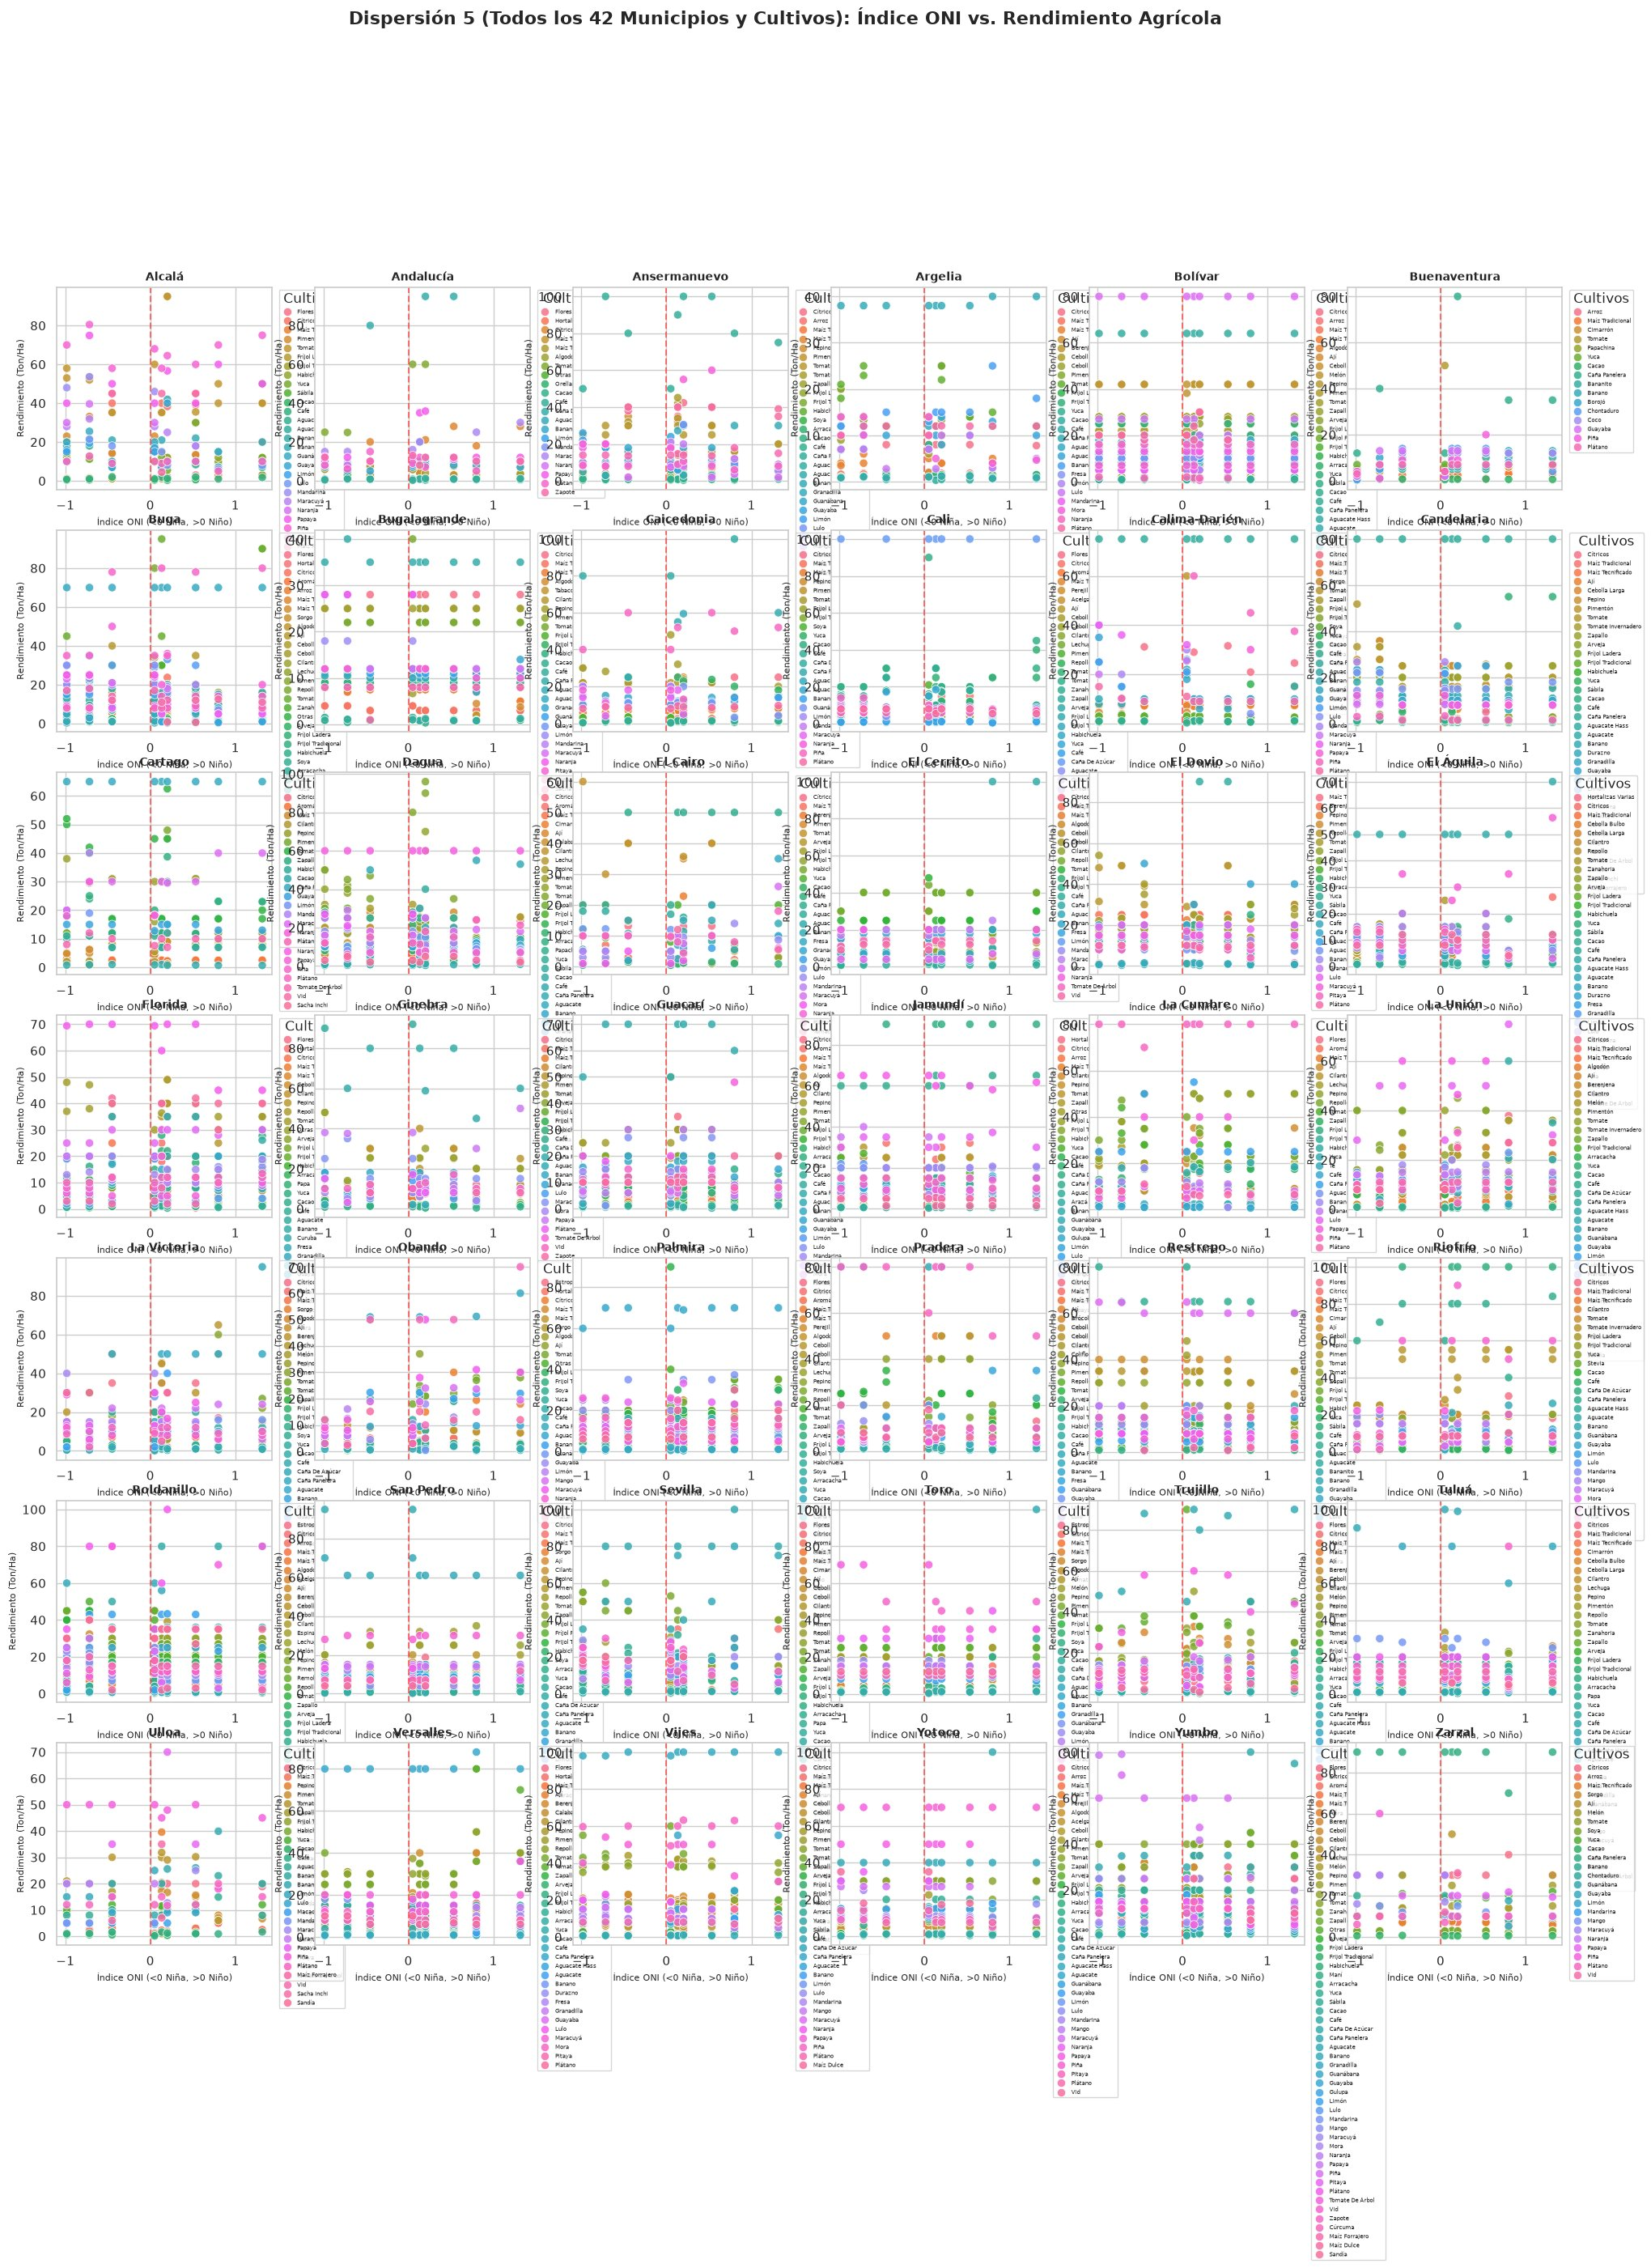

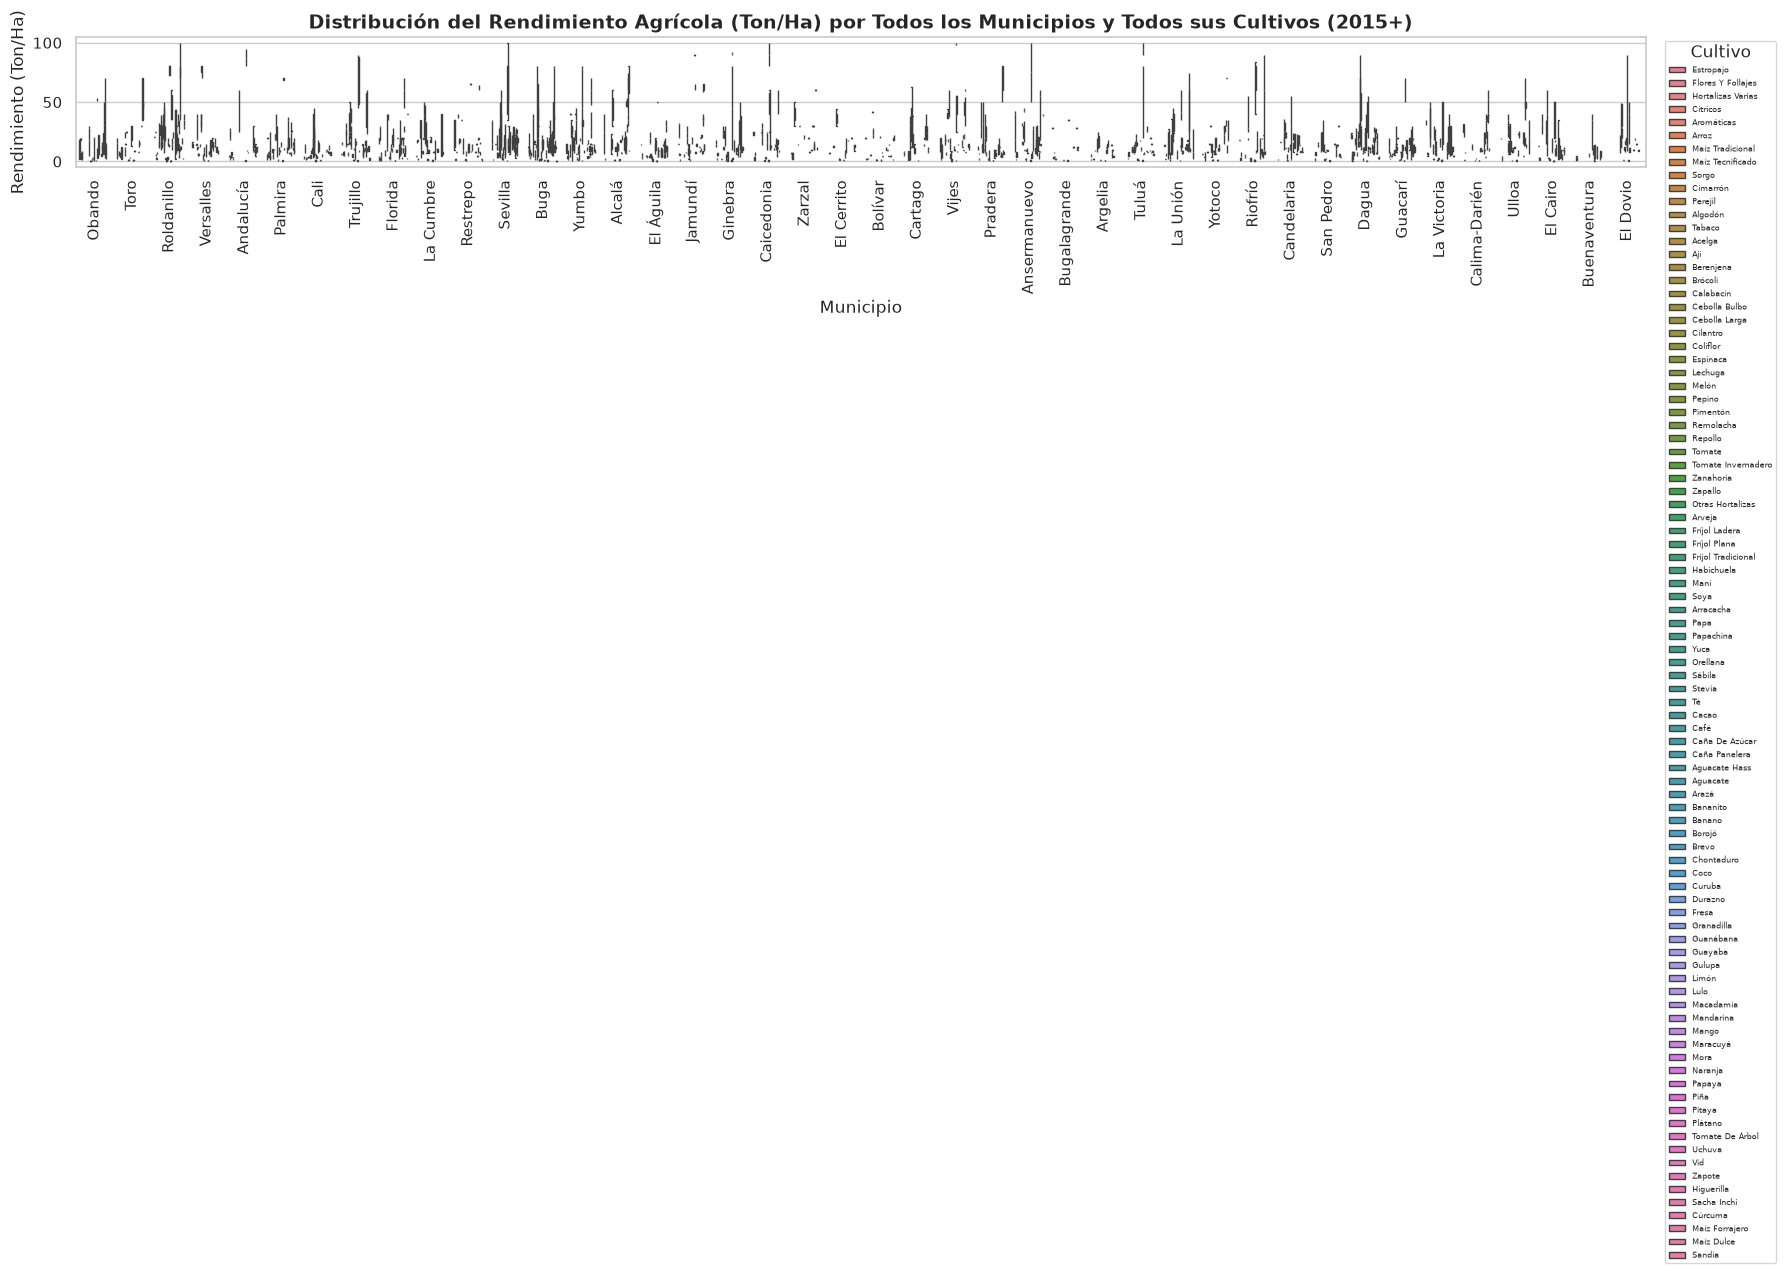

In [5]:
# Dispersión 5: Índice ONI vs. Rendimiento Agrícola (Todos los Municipios y Cultivos)
plot_grid_completo(df_rend_val, 'promedio_oni', 'rendimiento_toneladas_ha', 'Índice ONI (<0 Niña, >0 Niño)', 'Rendimiento (Ton/Ha)', 
                   'Dispersión 5 (Todos los 42 Municipios y Cultivos): Índice ONI vs. Rendimiento Agrícola', use_log_x=False, use_log_y=False, draw_oni_line=True)

# Boxplot por Todos los Municipios y Cultivos
plt.figure(figsize=(18, 8))
sns.boxplot(data=df_rend_val, x='municipio', y='rendimiento_toneladas_ha', hue='cultivo', showfliers=False)
plt.title('Distribución del Rendimiento Agrícola (Ton/Ha) por Todos los Municipios y Todos sus Cultivos (2015+)', fontsize=14, fontweight='bold')
plt.xlabel('Municipio', fontsize=12)
plt.ylabel('Rendimiento (Ton/Ha)', fontsize=12)
plt.xticks(rotation=90)
h, l = plt.gca().get_legend_handles_labels()
if h:
    plt.legend(h, l, title='Cultivo', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=6)
plt.tight_layout()
plt.show()

## 5. Matrices de Correlación Multivariable por Municipio

Analizamos las matrices de correlación interna para municipios representativos del departamento, observando las dinámicas intervariables entre sus cultivos.

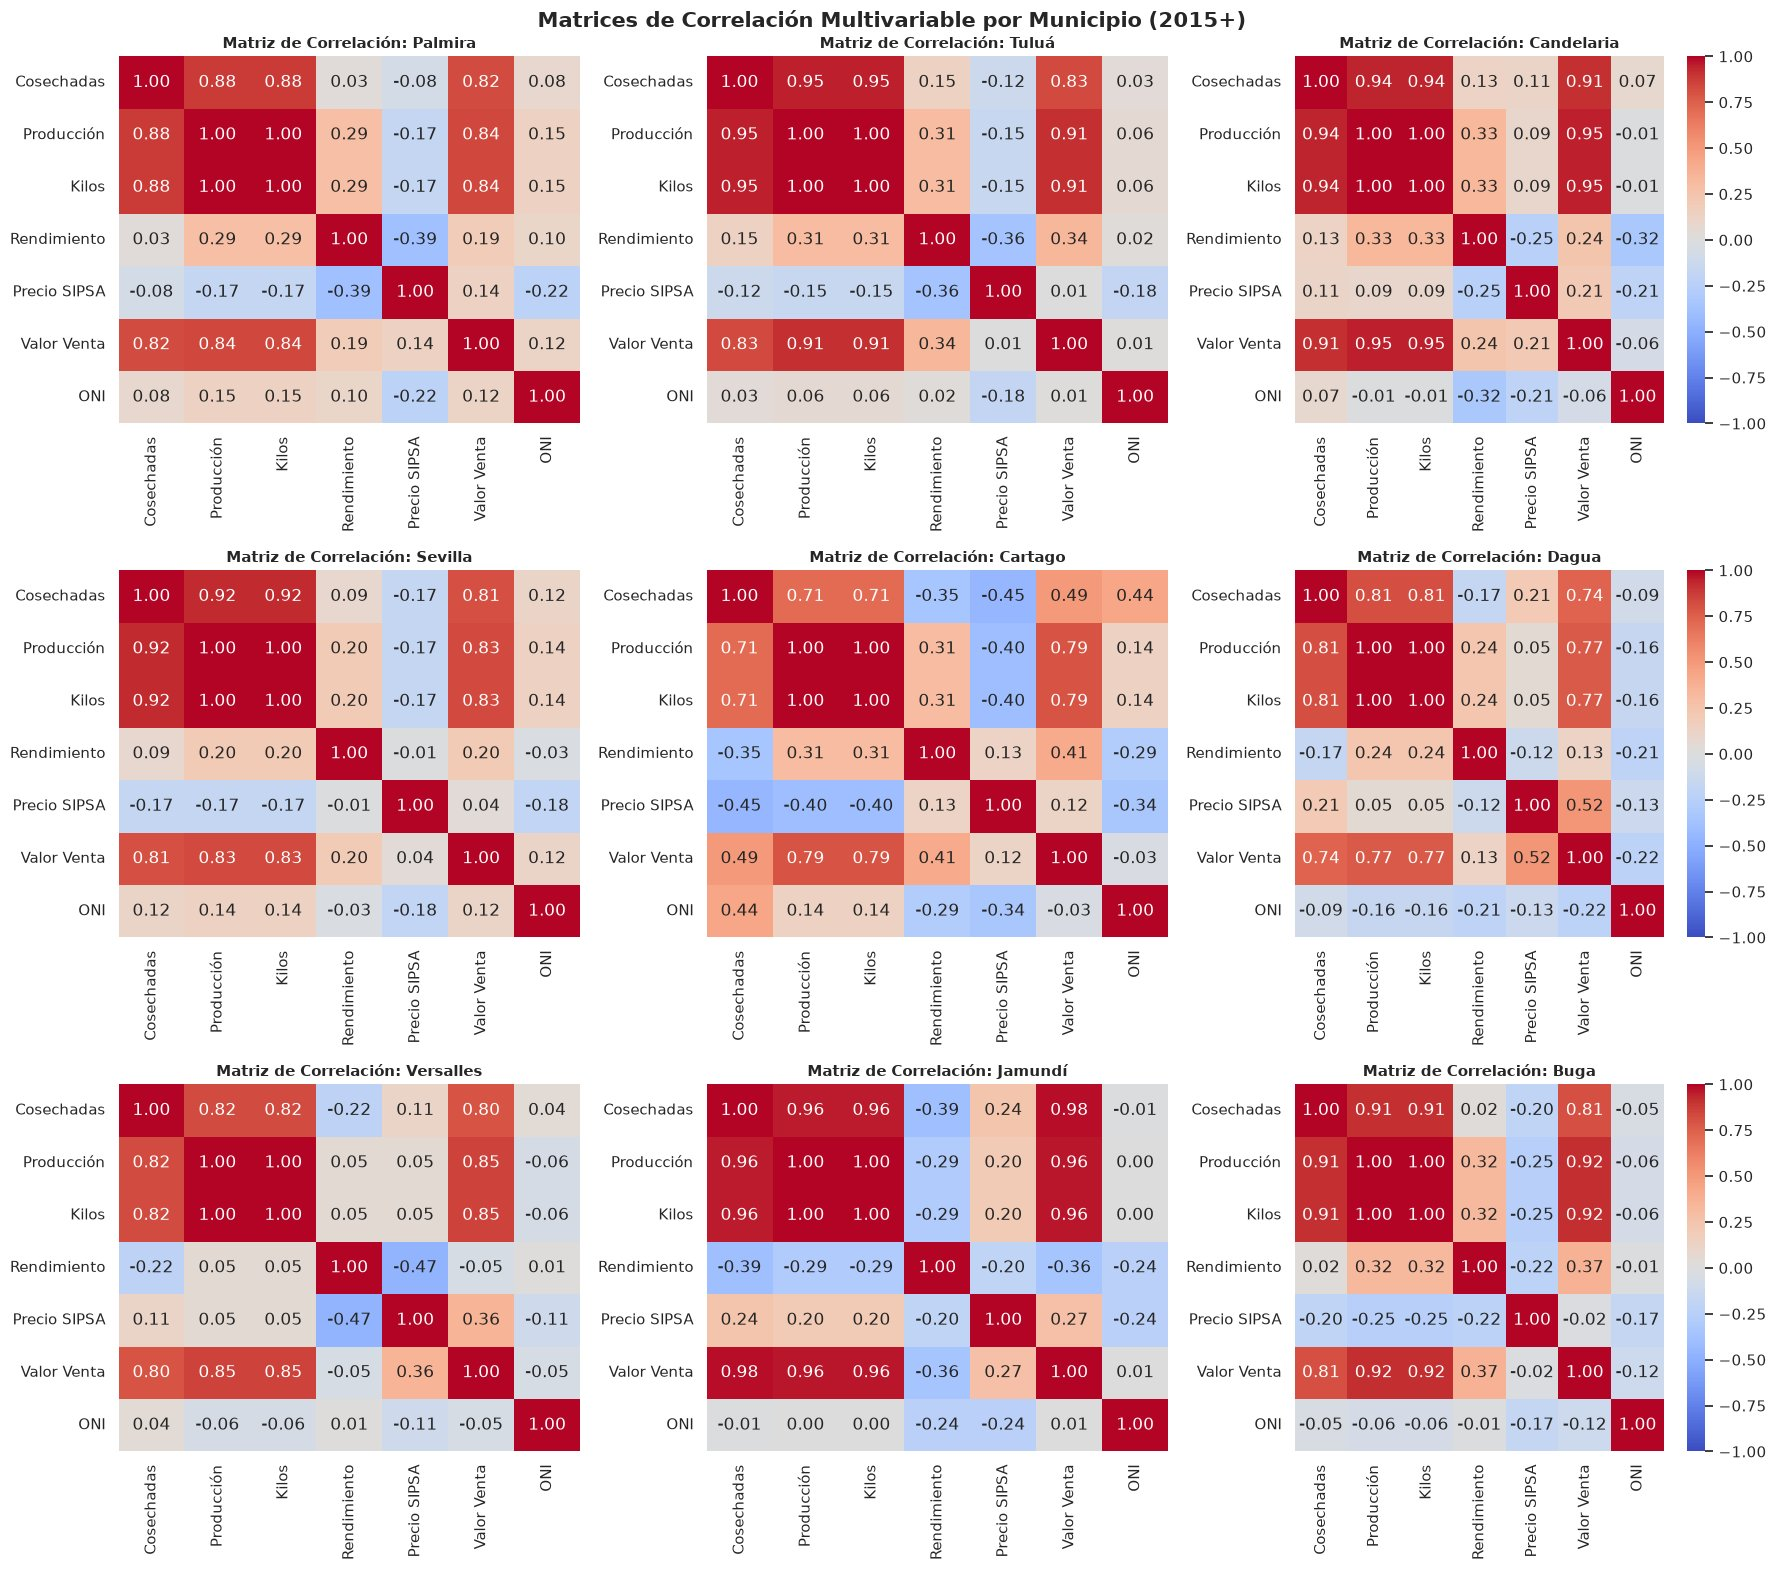

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()
cols_corr = ['hectareas_cosechadas', 'produccion_toneladas', 'kilos_cosechados', 'rendimiento_toneladas_ha', 'precio_promedio_anual_sipsa', 'valor_venta_millones', 'promedio_oni']
nombres_corr = ['Cosechadas', 'Producción', 'Kilos', 'Rendimiento', 'Precio SIPSA', 'Valor Venta', 'ONI']
muns_matriz = ['Palmira', 'Tuluá', 'Candelaria', 'Sevilla', 'Cartago', 'Dagua', 'Versalles', 'Jamundí', 'Buga']
for idx, mun in enumerate(muns_matriz):
    df_m = df[df['municipio'] == mun][cols_corr].dropna()
    if len(df_m) > 0:
        sns.heatmap(df_m.corr(), ax=axes[idx], annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, xticklabels=nombres_corr, yticklabels=nombres_corr, cbar=(idx%3==2))
    axes[idx].set_title(f'Matriz de Correlación: {mun}', fontsize=11, fontweight='bold')
plt.suptitle('Matrices de Correlación Multivariable por Municipio (2015+)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Conclusiones y Resumen del EDA Municipio a Municipio por Cultivo (2015-2024)

### Q&A
- **¿Por qué la visualización municipio a municipio analizando sus varios cultivos resolvió la interpretación agronómica?**  
  Cada municipio del Valle del Cauca posee condiciones geográficas y de suelo distintas. Al estructurar el estudio **municipio a municipio** y graficar dentro de cada territorio sus varios cultivos en subplots independientes, se aprecia claramente cómo en **Tuluá** conviven el Tomate y la Habichuela con precios estables, mientras en **Sevilla** predomina el Plátano y el Café, y en **Candelaria** la Caña panelera.
- **¿Qué revelan los diagramas por municipio sobre el rendimiento y precios SIPSA?**  
  En municipios de ladera (ej. Tuluá, Sevilla, Dagua), los varios cultivos hortícolas y frutales muestran mayor volatilidad ante el clima ONI que los cultivos extensivos planos de Candelaria o Palmira.

### Data Analysis Key Findings
- **Enfoque Municipio a Municipio:** Todos los gráficos de dispersión y correlación utilizan subplots dedicados por municipio mostrando sus distintos cultivos (`hue='cultivo'`).
- **Depuración Agronómica:** Filtro $0 < \text{Rendimiento} \le 100\text{ Ton}/\text{Ha}$ aplicado homogéneamente.

### Insights or Next Steps
1. **Modelos Predictivos Regionales por Municipio:** Utilizar el dataset agrupado por municipio y cultivo (`data/eda_resumen_municipio_producto.csv`) para personalizar sugerencias agrícolas por municipio.